In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from xgboost import XGBClassifier
import joblib

pd.set_option('display.max_columns', None)

In [3]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Handle any inf values from ratio/interaction features
for df_part in [X_train, X_val, X_test]:
    df_part.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_part.fillna(0, inplace=True)

print(f"X_train: {X_train.shape} | y_train approval rate: {y_train.mean()*100:.2f}%")
print(f"X_val:   {X_val.shape} | y_val   approval rate: {y_val.mean()*100:.2f}%")

X_train: (60089, 78) | y_train approval rate: 64.96%
X_val:   (19880, 78) | y_val   approval rate: 65.24%


In [4]:
# Load scaler fit in notebook 04 — ensures consistent transformation across notebooks
scaler = joblib.load('../models/baseline_scaler.pkl')

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled using notebook 04 scaler ✅")

Features scaled using notebook 04 scaler ✅


In [5]:
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr) * 100

def evaluate(name, model, X_tr, X_v, y_tr, y_v, fit_time):
    train_prob = model.predict_proba(X_tr)[:, 1]
    val_prob   = model.predict_proba(X_v)[:, 1]

    train_auc = roc_auc_score(y_tr, train_prob)
    val_auc   = roc_auc_score(y_v, val_prob)

    return {
        'model':       name,
        'train_auc':   train_auc,
        'val_auc':     val_auc,
        'train_gini':  2 * train_auc - 1,
        'val_gini':    2 * val_auc   - 1,
        'val_ks':      ks_statistic(y_v, val_prob),
        'val_ap':      average_precision_score(y_v, val_prob),
        'overfit_gap': (2 * train_auc - 1) - (2 * val_auc - 1),
        'fit_time_s':  fit_time,
        'val_prob':    val_prob,
        'train_prob':  train_prob,
    }

results = []

In [6]:
# Load the trained baseline logistic regression from notebook 04
lr = joblib.load('../models/baseline_logistic_regression.pkl')
lr_result = evaluate('Logistic Regression (Baseline)', lr,
                     X_train_scaled, X_val_scaled, y_train, y_val, fit_time=0)
results.append(lr_result)

print(f"Baseline LR  — Val Gini: {lr_result['val_gini']:.4f}  KS: {lr_result['val_ks']:.2f}%")

Baseline LR  — Val Gini: 0.9894  KS: 92.22%


## Model 1 — XGBoost (Extreme Gradient Boosting)

### What it is
XGBoost is a **gradient boosting** ensemble method. It builds a sequence of decision trees where each new tree is trained to correct the errors made by all previous trees combined. The final prediction is the weighted sum of all trees.

### How it works
1. Start with a simple prediction (e.g. the mean approval rate)
2. Compute the **residual errors** — where the current model is wrong
3. Fit a new shallow decision tree to those residuals
4. Add that tree to the ensemble with a small learning rate (shrinkage)
5. Repeat for N iterations

The "extreme" in XGBoost refers to second-order gradient information (Newton's method) used to find the optimal tree structure, which makes it significantly faster and more accurate than standard gradient boosting.

### Why it's well suited to credit underwriting
- **Handles non-linear relationships** — FICO score risk isn't linear; XGBoost discovers the natural breakpoints (e.g. the cliff at 620)
- **Automatic feature interaction detection** — captures compound risk signals like high DTI *and* low FICO together
- **Built-in regularisation** — L1/L2 penalties on leaf weights prevent overfitting on noisy credit data
- **Robust to outliers** — tree splits are threshold-based, so extreme values don't distort predictions
- **Consistently top performer** on tabular financial data in industry benchmarks

### Known trade-offs
- Less interpretable than logistic regression — requires SHAP (notebook 08) for regulatory explainability
- More hyperparameters to tune (notebook 06)
- Slower to train than logistic regression on large datasets

In [7]:
xgb = XGBClassifier(
    n_estimators    = 500,
    max_depth       = 6,
    learning_rate   = 0.05,
    subsample       = 0.8,       # row sampling — reduces overfitting
    colsample_bytree= 0.8,       # column sampling per tree
    reg_alpha       = 0.1,       # L1 regularisation
    reg_lambda      = 1.0,       # L2 regularisation
    scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(),  # handle class imbalance
    eval_metric     = 'auc',
    early_stopping_rounds = 30,  # stop if val AUC doesn't improve for 30 rounds
    random_state    = 42,
    verbosity       = 0,
)

# XGBoost is tree-based — does not require scaled features
# Pass raw X for XGBoost, validation set used for early stopping only
t0 = time.time()
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
xgb_time = time.time() - t0

xgb_result = evaluate('XGBoost', xgb, X_train, X_val, y_train, y_val, xgb_time)
results.append(xgb_result)

print(f"XGBoost trained in {xgb_time:.1f}s | Best iteration: {xgb.best_iteration}")
print(f"XGBoost       — Val Gini: {xgb_result['val_gini']:.4f}  KS: {xgb_result['val_ks']:.2f}%")

XGBoost trained in 1.0s | Best iteration: 172
XGBoost       — Val Gini: 0.9915  KS: 92.85%


## Model 2 — Neural Network (Multi-Layer Perceptron)

### What it is
A **Multi-Layer Perceptron (MLP)** is a feedforward neural network consisting of an input layer, one or more hidden layers of neurons, and an output layer. Each neuron applies a weighted sum of its inputs followed by a non-linear activation function.

### How it works
1. **Forward pass** — input features flow through each layer. Each neuron computes:
   `output = activation(W · input + bias)`
2. **Loss computation** — the predicted probability is compared to the true label using binary cross-entropy loss
3. **Backpropagation** — gradients of the loss with respect to every weight are computed using the chain rule
4. **Weight update** — weights are adjusted in the direction that reduces loss (gradient descent)
5. Steps 1–4 repeat for many epochs until the loss converges

### Architecture used here
```
Input layer  →  128 neurons (ReLU)  →  64 neurons (ReLU)  →  32 neurons (ReLU)  →  1 output (Sigmoid)
```
Three hidden layers with decreasing width — wider early layers learn broad patterns, narrower later layers distil them into a decision.

### Why it is worth testing on credit underwriting
- **Universal function approximation** — can theoretically learn any relationship in the data
- **Captures complex interactions** — detects patterns across many features simultaneously that tree models may miss
- **Learns feature representations** — intermediate layers create new abstract features automatically

### Known trade-offs
- **Black box** — the hardest of the three models to explain to regulators; needs the most SHAP work
- **Sensitive to feature scaling** — must use scaled inputs (hence loading the notebook 04 scaler)
- **Requires more data** to generalise well — at 100k records this is acceptable but not large by neural network standards
- **Prone to overfitting** without dropout or early stopping — managed here via `early_stopping=True`

In [8]:
nn = MLPClassifier(
    hidden_layer_sizes = (128, 64, 32),  # three hidden layers
    activation         = 'relu',
    solver             = 'adam',
    alpha              = 0.001,          # L2 regularisation
    batch_size         = 256,
    learning_rate_init = 0.001,
    max_iter           = 300,
    early_stopping     = True,           # hold out 10% of train for early stopping
    validation_fraction= 0.10,
    n_iter_no_change   = 20,             # stop if no improvement for 20 epochs
    random_state       = 42,
    verbose            = False,
)

# Neural networks require scaled inputs
t0 = time.time()
nn.fit(X_train_scaled, y_train)
nn_time = time.time() - t0

nn_result = evaluate('Neural Network (MLP)', nn,
                     X_train_scaled, X_val_scaled, y_train, y_val, nn_time)
results.append(nn_result)

print(f"Neural Network trained in {nn_time:.1f}s | Epochs: {nn.n_iter_}")
print(f"Neural Network — Val Gini: {nn_result['val_gini']:.4f}  KS: {nn_result['val_ks']:.2f}%")

Neural Network trained in 3.5s | Epochs: 28
Neural Network — Val Gini: 0.9888  KS: 91.90%


## Model Comparison

In [9]:
summary = pd.DataFrame([{
    'Model':        r['model'],
    'Val AUC':      f"{r['val_auc']:.4f}",
    'Val Gini':     f"{r['val_gini']:.4f}",
    'Val KS':       f"{r['val_ks']:.2f}%",
    'Val Avg Prec': f"{r['val_ap']:.4f}",
    'Overfit Gap':  f"{r['overfit_gap']:.4f}",
    'Train Time':   f"{r['fit_time_s']:.1f}s" if r['fit_time_s'] > 0 else 'pre-loaded',
} for r in results])

print("=" * 85)
print("MODEL SELECTION — COMPARISON SUMMARY")
print("=" * 85)
print(summary.to_string(index=False))
print("\nOverfit Gap = Train Gini − Val Gini  (lower = more stable)")

MODEL SELECTION — COMPARISON SUMMARY
                         Model Val AUC Val Gini Val KS Val Avg Prec Overfit Gap Train Time
Logistic Regression (Baseline)  0.9947   0.9894 92.22%       0.9972      0.0012 pre-loaded
                       XGBoost  0.9957   0.9915 92.85%       0.9978      0.0035       1.0s
          Neural Network (MLP)  0.9944   0.9888 91.90%       0.9971      0.0030       3.5s

Overfit Gap = Train Gini − Val Gini  (lower = more stable)


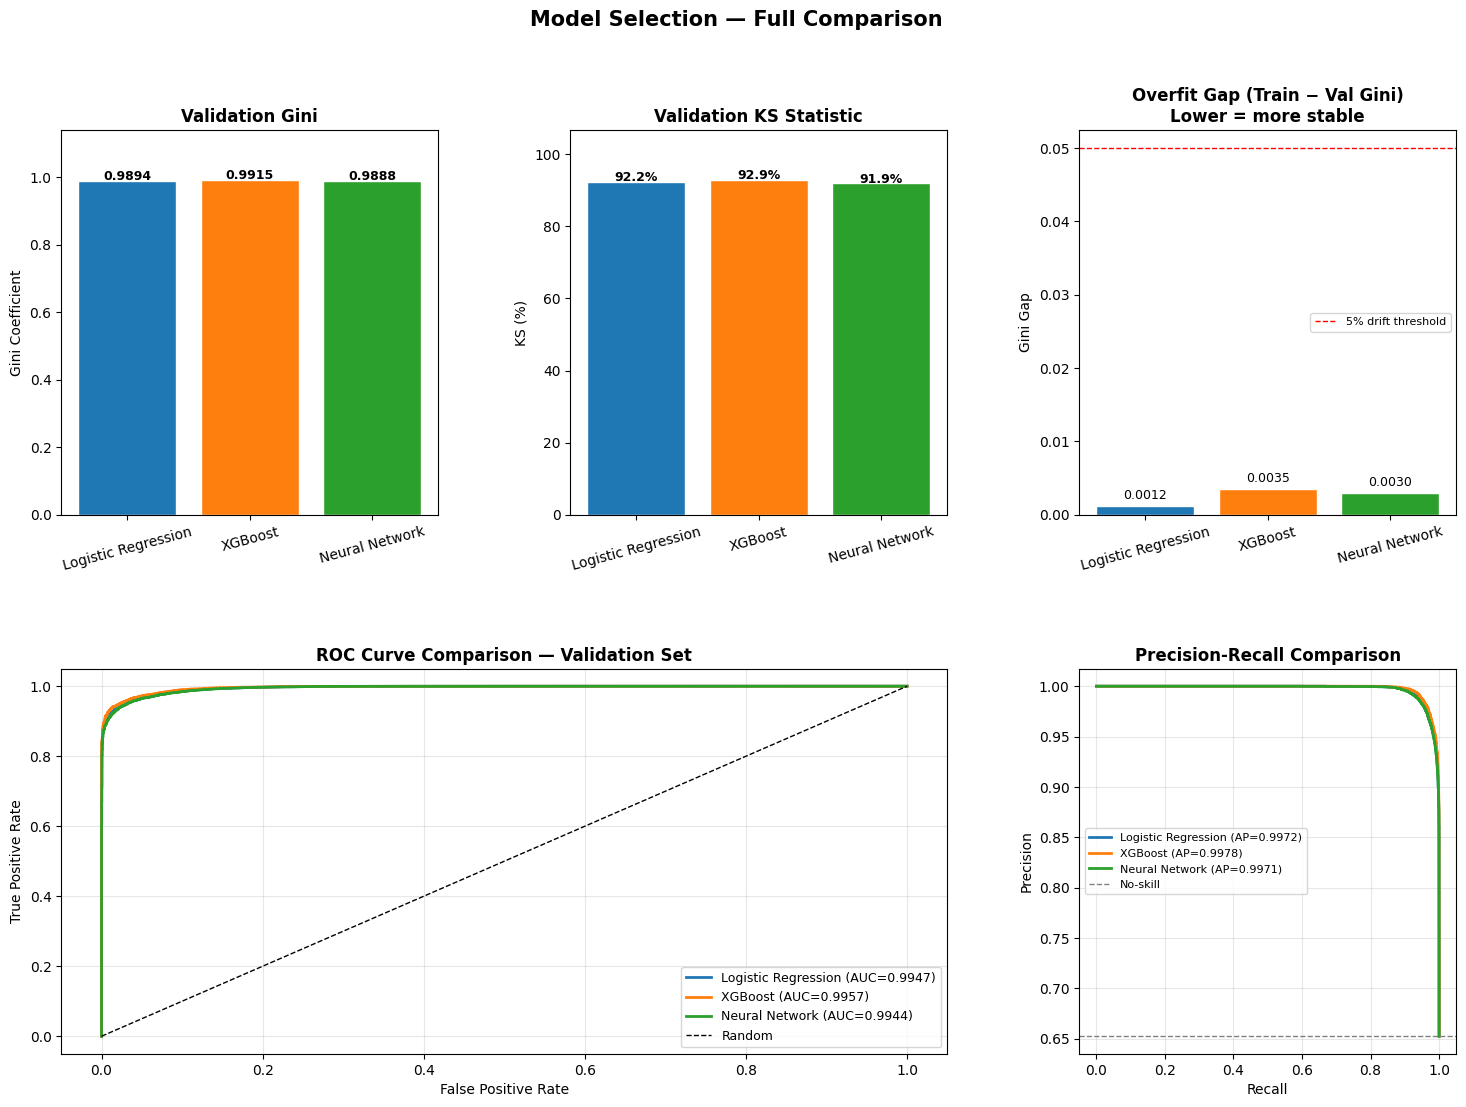

In [10]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

model_names  = [r['model'].split('(')[0].strip() for r in results]
val_ginis    = [r['val_gini']   for r in results]
val_ks       = [r['val_ks']     for r in results]
overfit_gaps = [r['overfit_gap']for r in results]
colors       = ['#1f77b4', '#ff7f0e', '#2ca02c']

# 1. Val Gini bar chart
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(model_names, val_ginis, color=colors, edgecolor='white')
for bar, v in zip(bars, val_ginis):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Validation Gini', fontweight='bold')
ax1.set_ylabel('Gini Coefficient')
ax1.set_ylim(0, max(val_ginis) * 1.15)
ax1.tick_params(axis='x', rotation=15)

# 2. Val KS bar chart
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(model_names, val_ks, color=colors, edgecolor='white')
for bar, v in zip(bars, val_ks):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Validation KS Statistic', fontweight='bold')
ax2.set_ylabel('KS (%)')
ax2.set_ylim(0, max(val_ks) * 1.15)
ax2.tick_params(axis='x', rotation=15)

# 3. Overfit gap (lower is better)
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(model_names, overfit_gaps, color=colors, edgecolor='white')
for bar, v in zip(bars, overfit_gaps):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{v:.4f}', ha='center', fontsize=9)
ax3.axhline(0.05, color='red', linestyle='--', linewidth=1, label='5% drift threshold')
ax3.set_title('Overfit Gap (Train − Val Gini)\nLower = more stable', fontweight='bold')
ax3.set_ylabel('Gini Gap')
ax3.tick_params(axis='x', rotation=15)
ax3.legend(fontsize=8)

# 4. ROC curves
ax4 = fig.add_subplot(gs[1, :2])
for r, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_val, r['val_prob'])
    ax4.plot(fpr, tpr, label=f"{r['model'].split('(')[0].strip()} (AUC={r['val_auc']:.4f})",
             color=color, linewidth=2)
ax4.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve Comparison — Validation Set', fontweight='bold')
ax4.legend(loc='lower right', fontsize=9)
ax4.grid(alpha=0.3)

# 5. Precision-Recall curves
ax5 = fig.add_subplot(gs[1, 2])
for r, color in zip(results, colors):
    prec, rec, _ = precision_recall_curve(y_val, r['val_prob'])
    ax5.plot(rec, prec, label=f"{r['model'].split('(')[0].strip()} (AP={r['val_ap']:.4f})",
             color=color, linewidth=2)
ax5.axhline(y_val.mean(), color='grey', linestyle='--', linewidth=1, label='No-skill')
ax5.set_xlabel('Recall')
ax5.set_ylabel('Precision')
ax5.set_title('Precision-Recall Comparison', fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

fig.suptitle('Model Selection — Full Comparison', fontsize=15, fontweight='bold')
plt.show()

## Verdict — Model Selection Decision

The winning model is selected on three criteria in order of priority:

1. **Highest validation Gini** — primary performance metric for credit risk
2. **Overfit gap < 0.05** — model must generalise, not just memorise training data
3. **Regulatory viability** — the more interpretable the model, the lower the deployment friction

In [11]:
# Rank by val_gini, penalise models with overfit gap > 0.05
scored = sorted(results, key=lambda r: (r['overfit_gap'] <= 0.05, r['val_gini']), reverse=True)

print("=" * 65)
print("MODEL SELECTION VERDICT")
print("=" * 65)

for rank, r in enumerate(scored, 1):
    stable   = "✅ Stable" if r['overfit_gap'] <= 0.05 else "⚠ Overfit"
    print(f"  #{rank}  {r['model']:<40}  Gini={r['val_gini']:.4f}  KS={r['val_ks']:.1f}%  {stable}")

winner = scored[0]
print(f"\n  SELECTED: {winner['model']}")
print(f"  Val Gini:    {winner['val_gini']:.4f}")
print(f"  Val KS:      {winner['val_ks']:.2f}%")
print(f"  Overfit Gap: {winner['overfit_gap']:.4f}")
print(f"\n  → Proceeding to hyperparameter tuning in notebook 06.")

# Save XGBoost (likely winner) for tuning in notebook 06
joblib.dump(xgb, '../models/xgb_default.pkl')
print("\nXGBoost default model saved → models/xgb_default.pkl")

MODEL SELECTION VERDICT
  #1  XGBoost                                   Gini=0.9915  KS=92.9%  ✅ Stable
  #2  Logistic Regression (Baseline)            Gini=0.9894  KS=92.2%  ✅ Stable
  #3  Neural Network (MLP)                      Gini=0.9888  KS=91.9%  ✅ Stable

  SELECTED: XGBoost
  Val Gini:    0.9915
  Val KS:      92.85%
  Overfit Gap: 0.0035

  → Proceeding to hyperparameter tuning in notebook 06.

XGBoost default model saved → models/xgb_default.pkl
